# 3D Grounding-DETR Visualization Demo

This notebook demonstrates how to visualize predictions from the 3D Grounding-DETR model on CT volumes.

In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from models import build_model
from datasets import RSNAVolumeDataset
from utils.visualization import (
    visualize_single_slice,
    visualize_multi_slice,
    save_visualization
)

%matplotlib inline

## 1. Load Model and Dataset

In [38]:
# Configuration
CHECKPOINT_PATH = 'checkpoints/model_final.pth'
DATA_DIR = './datasets'
SAMPLE_IDX = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

Using device: cpu


In [39]:
# Load checkpoint
print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
config = checkpoint['config']

# Build model
print("Building model...")
model = build_model(config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

Loading checkpoint from checkpoints/model_final.pth...
Building model...
Model built with 47,685,996 parameters
Model loaded successfully!


In [40]:
# Load dataset
print(f"Loading dataset from {DATA_DIR}...")
dataset = RSNAVolumeDataset(
    data_dir=DATA_DIR,
    volume_size=tuple(config['data']['image_size']),
    train=False,
    augment=False
)

print(f"Dataset size: {len(dataset)}")

Loading dataset from ./datasets...
Found 2 segmentation files
Dataset size: 2


## 2. Run Inference

In [41]:
# Get sample
sample = dataset[SAMPLE_IDX]
volume = sample['volume']  # (1, D, H, W)
study_id = sample['study_id']
gt_boxes = sample['boxes'].numpy()
gt_labels = sample['labels'].numpy()

print(f"Study ID: {study_id}")
print(f"Volume shape: {volume.shape}")
print(f"Ground truth objects: {len(gt_boxes)}")

Study ID: 21057
Volume shape: torch.Size([1, 64, 128, 128])
Ground truth objects: 5


In [42]:
# Run inference
print("Running inference...")
with torch.no_grad():
    volume_input = volume.unsqueeze(0).to(DEVICE).float()  # (1, 1, D, H, W)
    outputs = model(volume_input)
    
    pred_logits = outputs['pred_logits'][0]  # (num_queries, num_classes+1)
    pred_boxes = outputs['pred_boxes'][0]    # (num_queries, 6)
    
    # Get scores and labels
    pred_scores = pred_logits.softmax(-1)
    pred_labels = pred_scores[:, :-1].argmax(-1)  # Exclude background
    pred_scores = pred_scores.max(-1)[0]
    
    # Move to CPU
    pred_boxes = pred_boxes.cpu().numpy()
    pred_labels = pred_labels.cpu().numpy()
    pred_scores = pred_scores.cpu().numpy()

print("Inference complete!")

Running inference...
Inference complete!


In [43]:
# Filter predictions by score threshold
SCORE_THRESHOLD = 0.5

valid_mask = pred_scores >= SCORE_THRESHOLD
pred_boxes_filtered = pred_boxes[valid_mask]
pred_labels_filtered = pred_labels[valid_mask]
pred_scores_filtered = pred_scores[valid_mask]

print(f"Predictions (score >= {SCORE_THRESHOLD}): {len(pred_boxes_filtered)}")
for i, (box, label, score) in enumerate(zip(pred_boxes_filtered, pred_labels_filtered, pred_scores_filtered)):
    print(f"  {i+1}. Class {label}, Score: {score:.3f}")

Predictions (score >= 0.5): 13
  1. Class 0, Score: 0.501
  2. Class 4, Score: 0.556
  3. Class 4, Score: 0.609
  4. Class 4, Score: 0.509
  5. Class 3, Score: 0.600
  6. Class 2, Score: 0.570
  7. Class 4, Score: 0.515
  8. Class 0, Score: 0.525
  9. Class 4, Score: 0.533
  10. Class 4, Score: 0.619
  11. Class 2, Score: 0.509
  12. Class 4, Score: 0.532
  13. Class 4, Score: 0.517


## 3. Single-Slice Visualization

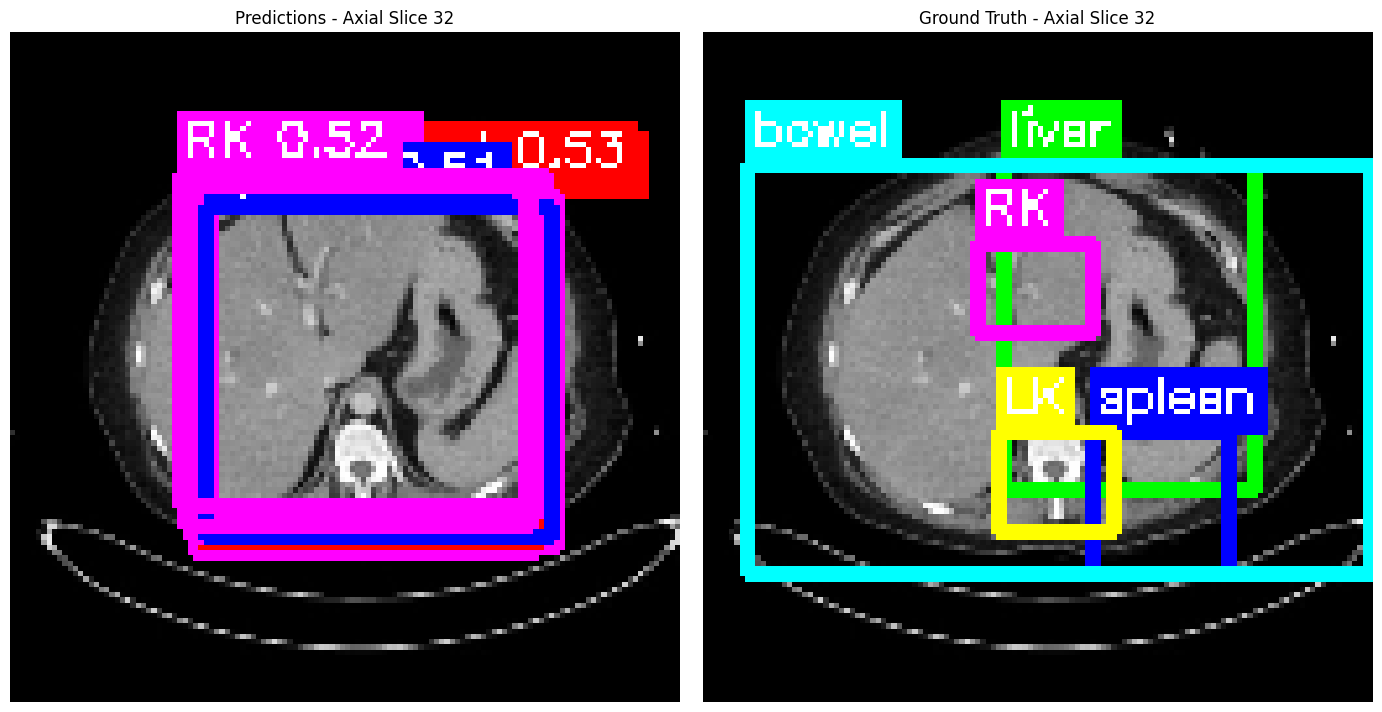

In [44]:
# Visualize middle slice
volume_np = volume[0].numpy()  # Remove channel dimension
middle_slice = volume_np.shape[0] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=middle_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='axial',
    score_threshold=SCORE_THRESHOLD,
    figsize=(14, 7)
)

plt.show()

## 4. Multi-Slice Visualization

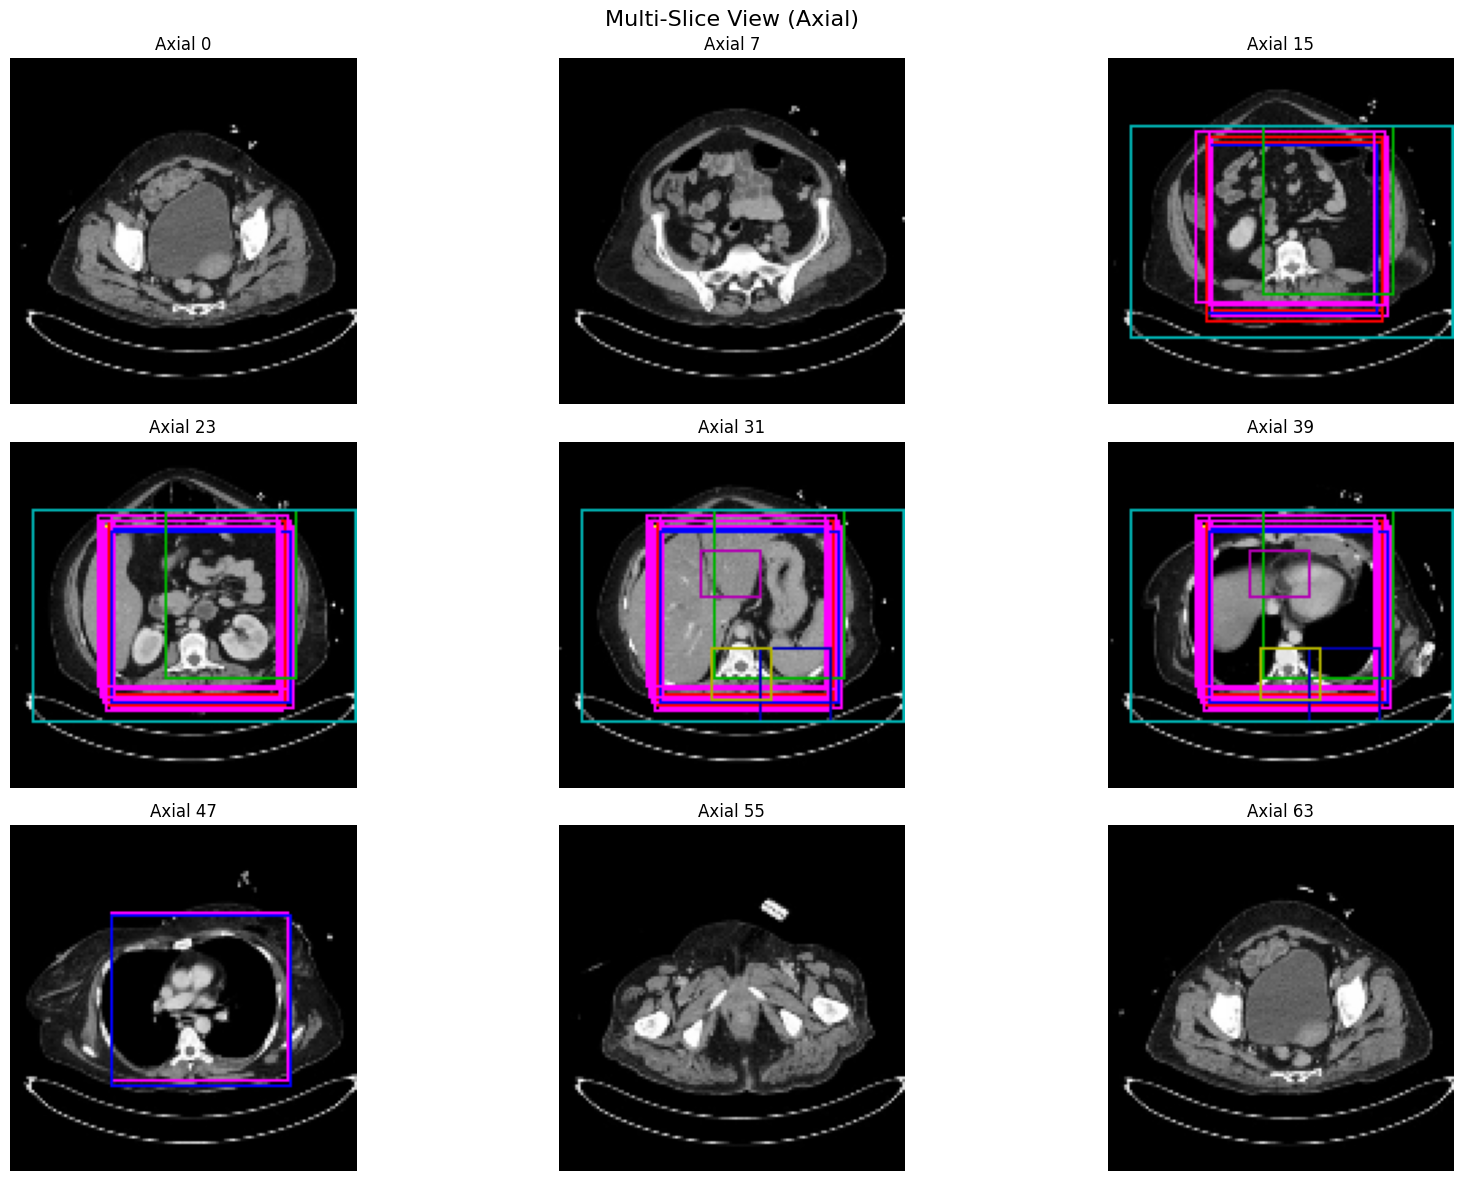

In [45]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=9,
    axis='axial',
    score_threshold=SCORE_THRESHOLD,
    figsize=(18, 12)
)

plt.show()

## 5. Different Views (Sagittal & Coronal)

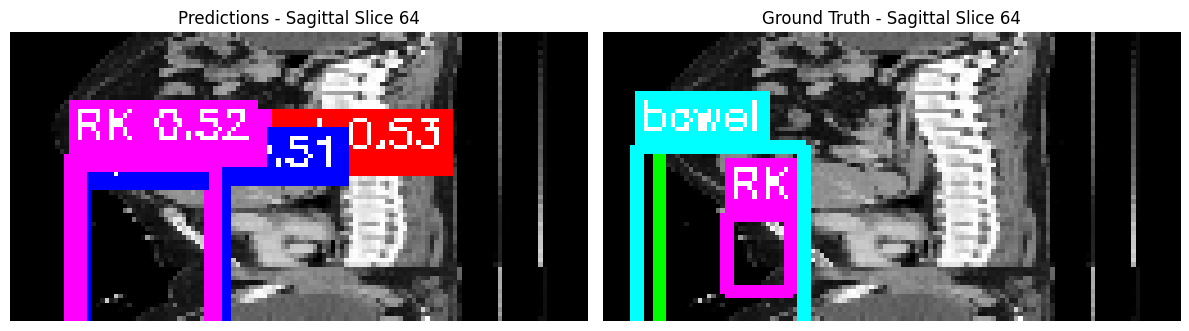

In [46]:
# Sagittal view (from the side)
sagittal_slice = volume_np.shape[2] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=sagittal_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='sagittal',
    score_threshold=SCORE_THRESHOLD
)

plt.show()

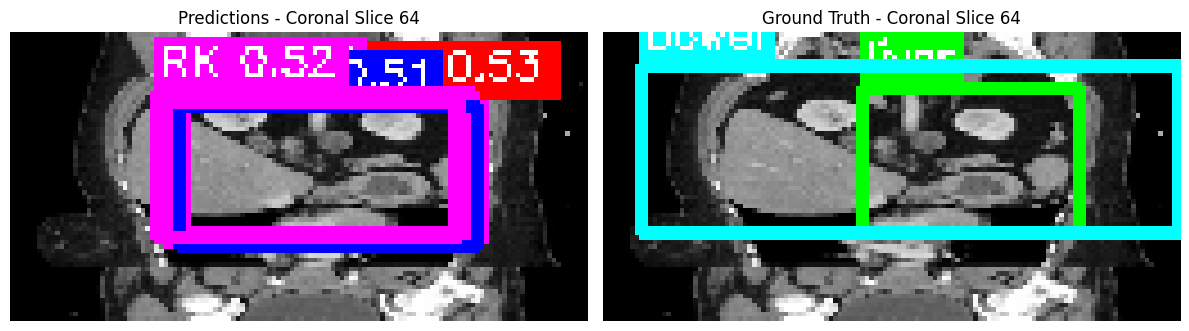

In [47]:
# Coronal view (from the front)
coronal_slice = volume_np.shape[1] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=coronal_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='coronal',
    score_threshold=SCORE_THRESHOLD
)

plt.show()

## 6. Save Visualizations

Saved visualization to demo_results/21057_multi_slice.png
Saved!


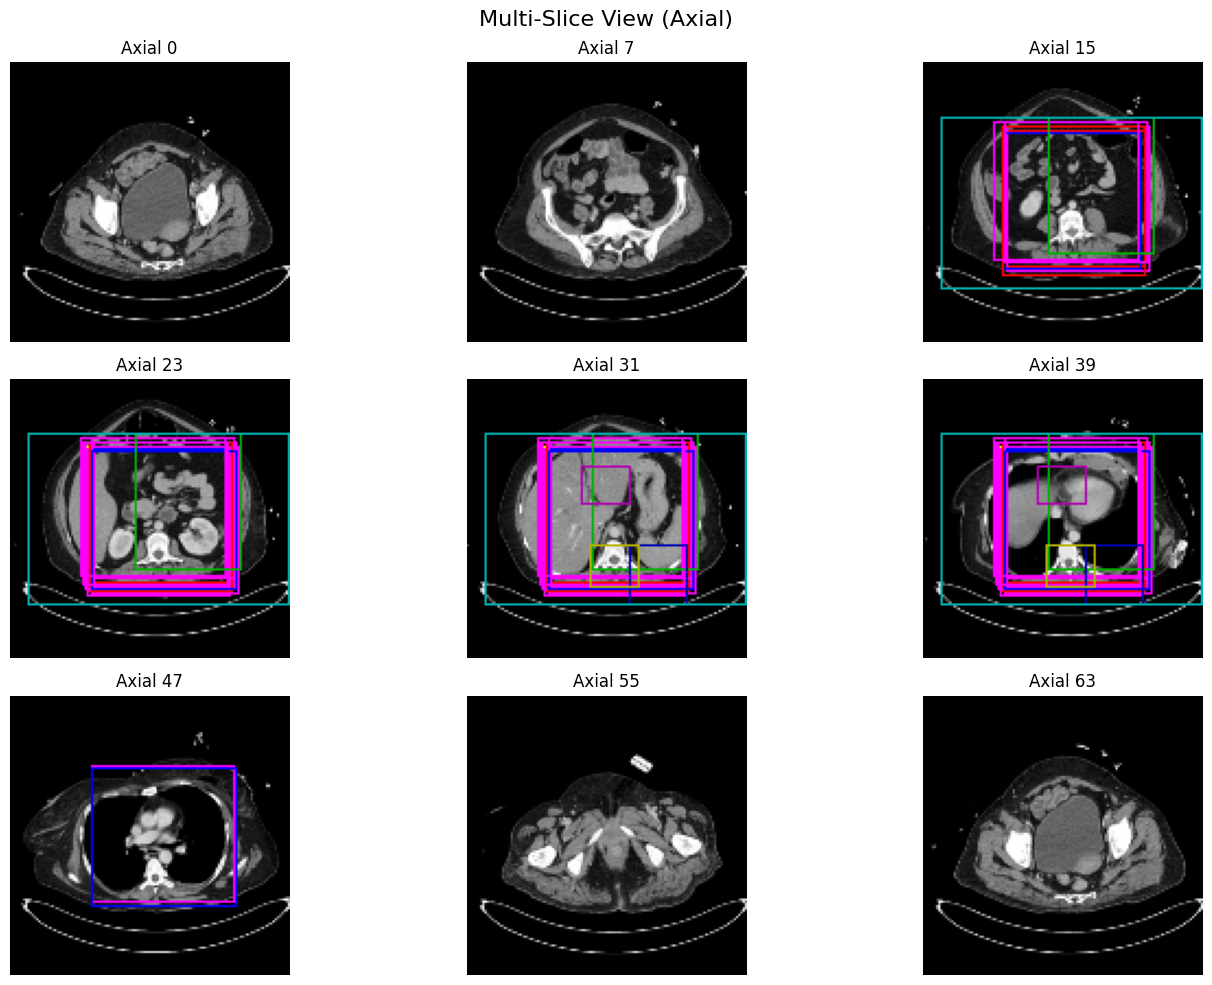

In [48]:
# Create output directory
output_dir = Path('./demo_results')
output_dir.mkdir(exist_ok=True)

# Save multi-slice view
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=9,
    score_threshold=SCORE_THRESHOLD
)

save_visualization(fig, str(output_dir / f"{study_id}_multi_slice.png"), dpi=200)
print("Saved!")